In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

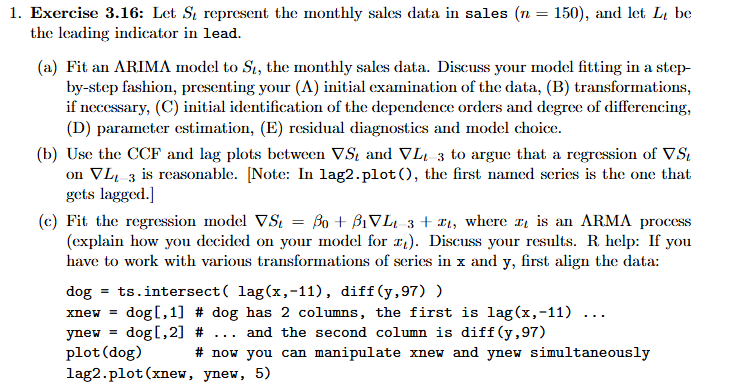

(a)

In [2]:
df = pd.read_csv("sales.csv")
df2 = pd.read_csv("lead.csv")
df['Lead'] = df2.iloc[:,1]

<Axes: xlabel='Time', ylabel='Value'>

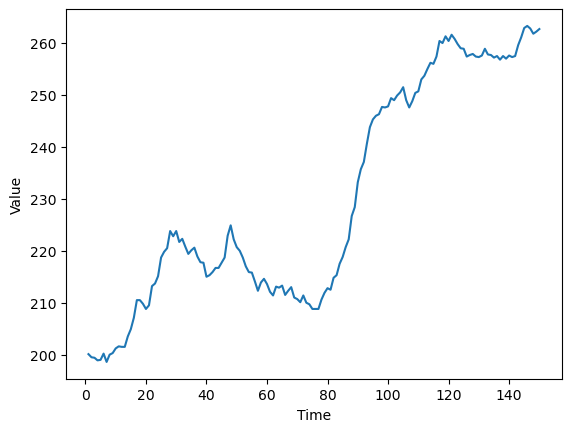

In [3]:
sns.lineplot(x=df['Time'], y=df['Value'])

<Axes: xlabel='Time', ylabel='Diff'>

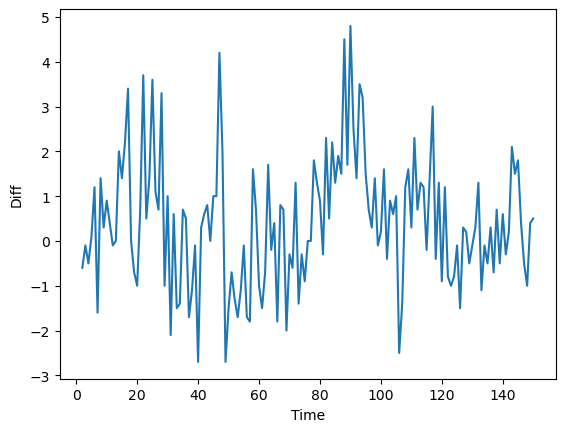

In [4]:
#clearly non-stationary so taking first difference
df['Diff'] = df['Value'].diff()
sns.lineplot(x=df['Time'], y=df['Diff'])

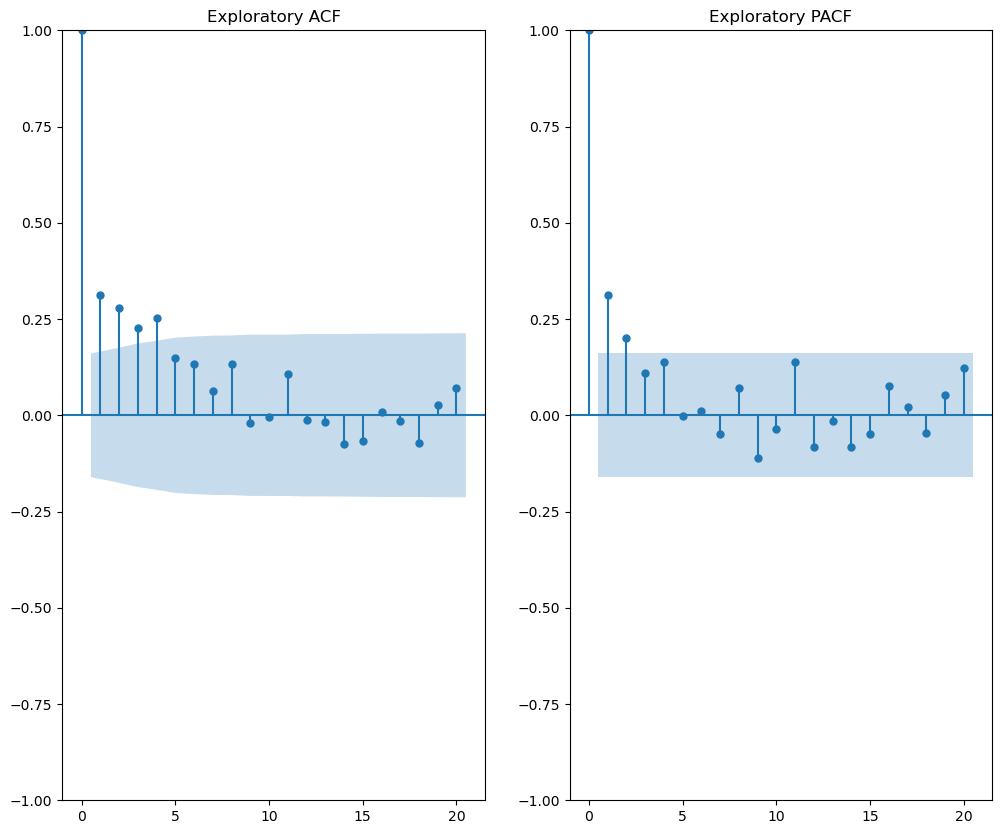

In [5]:
lags = 20
fig, axes = plt.subplots(1, 2, figsize=(12, 10))
plot_acf(df['Diff'].dropna(), ax=axes[0], lags=lags, title="Exploratory ACF")
plot_pacf(df['Diff'].dropna(), ax=axes[1], lags=lags, title="Exploratory PACF")
plt.show()

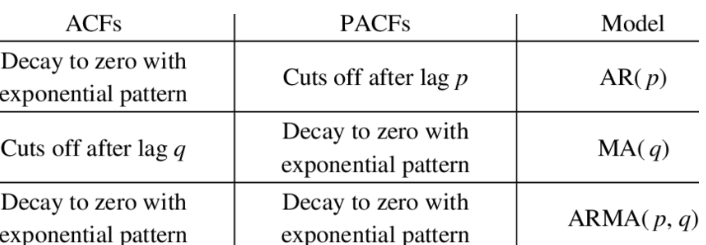

AIC = 519.9227827281478, BIC = 528.9346216459842


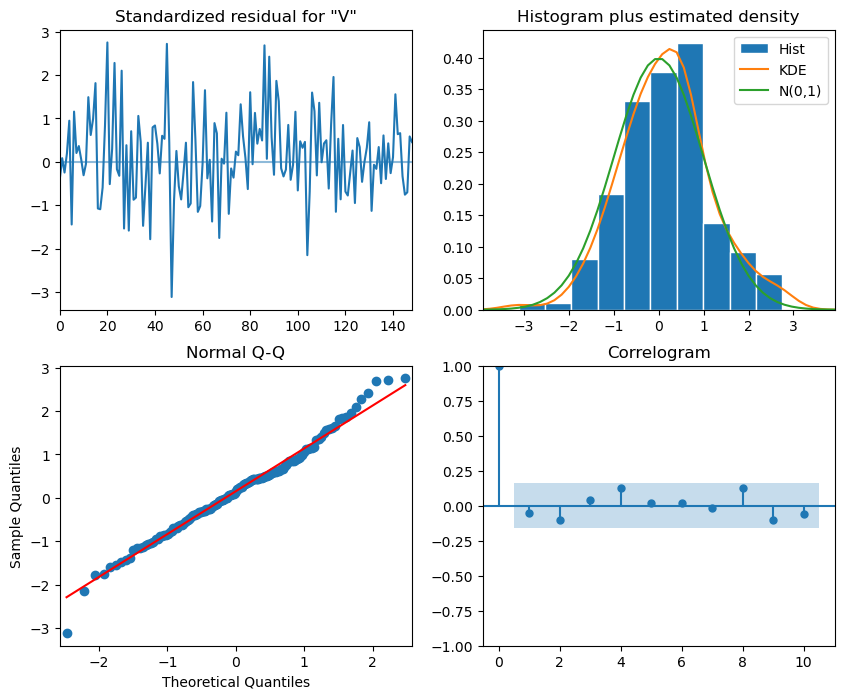

In [6]:
#first choice is ARIMA(2,1,0)
model = ARIMA(df['Value'], order = (2,1,0))
modelFit = model.fit()
AIC, BIC = modelFit.aic, modelFit.bic
modelFit.plot_diagnostics(figsize=(10,8))
print(f"AIC = {AIC}, BIC = {BIC}")
plt.show()

AIC = 526.126491155237, BIC = 532.1343837671279


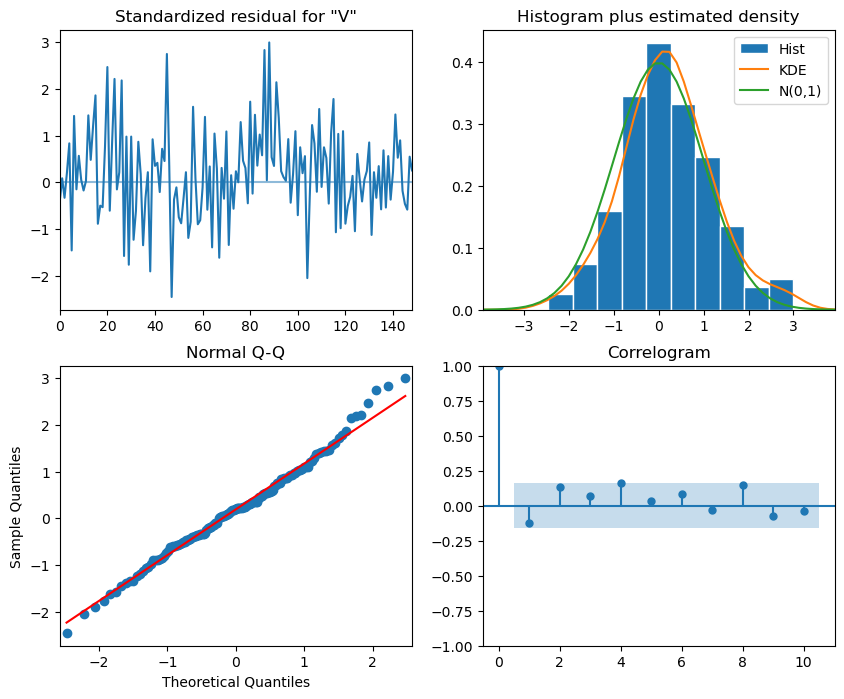

In [7]:
#compared to ARIMA(1,1,0)
model = ARIMA(df['Value'], order = (1,1,0))
modelFit = model.fit()
AIC, BIC = modelFit.aic, modelFit.bic
modelFit.plot_diagnostics(figsize=(10,8))
print(f"AIC = {AIC}, BIC = {BIC}")
plt.show()

Ultimately, the ARIMA(2,1,0) model proved to be the best fit for the data. This model was found by first plotting the time series which exposed a clear non-stationary trend. After the first difference was taken and the series was stationary, the ACF and PACFs were plotted. The ACF appeared to decay to zero while the PACF cut off sharply at lag 2 or lag 1. This gave us two models to test: ARIMA(2,1,0) and ARIMA(1,1,0). After fitting both models, their residual diagnostics were similar, but ARIMA(2,1,0) had a slightly lower AIC and BIC, thus being the better model for the data.

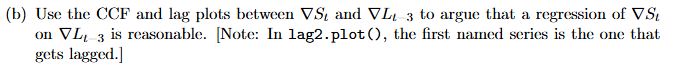

CCF Plot:


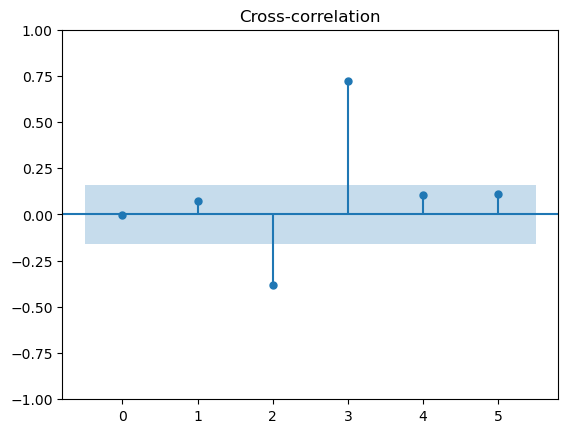

Lag Plot:


<Axes: xlabel='Lead', ylabel='Diff'>

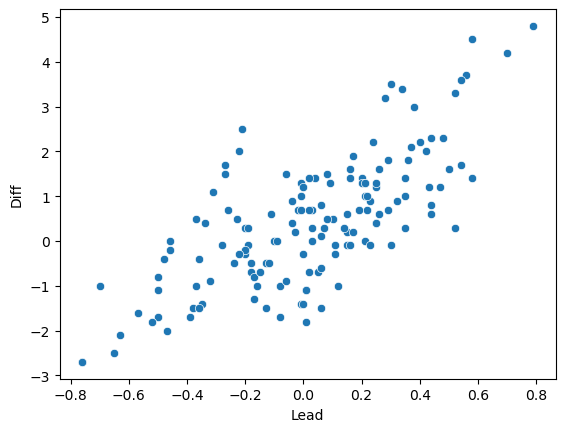

In [8]:
diff = df["Diff"]
lead = df["Lead"].diff() 
lagged = lead.shift(3)  
from statsmodels.graphics.tsaplots import plot_ccf
print("CCF Plot:")
plot_ccf(diff.dropna(), lead.dropna(), lags=5)
plt.show()
print("Lag Plot:")
sns.scatterplot(x=lagged, y=diff)

A regression of the differenced sales on the differenced lag at t-3 is a reasonable regression model as the CCF shows a clear cross correlation between the lead indicator and sales at a +3 lag. Further, the lag plot shows a clear linear trend between the differenced lead and differenced sales, suggesting a linear model is adequate.

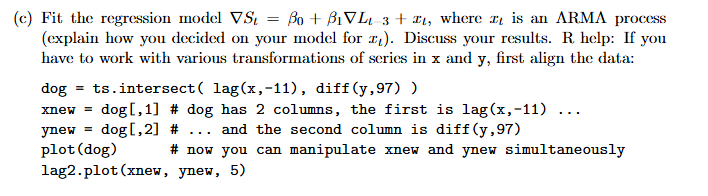

In [9]:
#Using an ARMA(1,0) since an ARIMA(2,1,0) fit the data well above and differencing in sales is already incorporated, however upon calculation the AR(2) term was stastitcally insignificant, suggesting an ARMA(1,0) was more appropriate.
from statsmodels.api import OLS
df = pd.DataFrame({'y': diff, 'x1': lagged})
df = df.dropna()
stmodel = ARIMA(endog=df['y'], exog=df['x1'], order=(1,0,0))
stfit = stmodel.fit()
stfit.summary()

C:\Users\jmeek\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\jmeek\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\jmeek\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  146
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -168.717
Date:                Sat, 25 Jul 2026   AIC                            345.433
Time:                        21:58:45   BIC                            357.368
Sample:                             0   HQIC                           350.282
                                - 146                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3624      0.191      1.897      0.058      -0.012       0.737
x1             2.7876      0.158     17.648      0.000       2.478       3.097
ar.L1          0.6451      0.062     10.388      0.000       0.523       0.767
sigma2         0.5884      0.070      8.375      0.000       0.451       0.726
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 0.12
Prob(Q):                              0.83   Prob(JB):                         0.94
Heteroskedasticity (H):               0.59   Skew:                             0.03
Prob(H) (two-sided):                  0.07   Kurtosis:                         3.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The coefficient for B1 is statistically significant, as is the AR(1) term, suggesting that the lagged lead is a good predictor and the ARMA(1,0) process captures the residual pattern better than white noise.

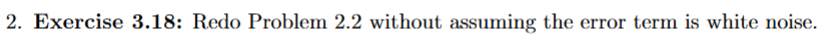
Problem 2.2:

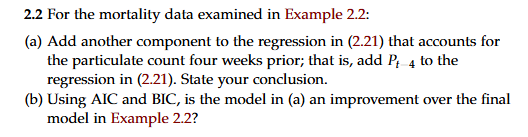

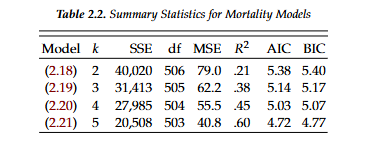

In [10]:
df = pd.read_csv("cmort.csv")
df1 = pd.read_csv("part.csv")
df2 = pd.read_csv("tempr.csv")
df = df.rename(columns={"Value": "Mortality"})
df['Particulates'] = df1.iloc[:,1]
df['Temperature'] = df2.iloc[:,1]
df['Particulates Lagged (4)'] = df['Particulates'].shift(4)
df['Temp Centered'] = df['Temperature'] - df['Temperature'].mean()
df['Temp Centered Squared'] = df['Temp Centered']**2
df['Time'] = np.arange(1, len(df) + 1)
df = df.dropna()

                            OLS Regression Results                            
Dep. Variable:              Mortality   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     154.5
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           7.42e-99
Time:                        21:58:47   Log-Likelihood:                -1638.8
No. Observations:                 504   AIC:                             3290.
Df Residuals:                     498   BIC:                             3315.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

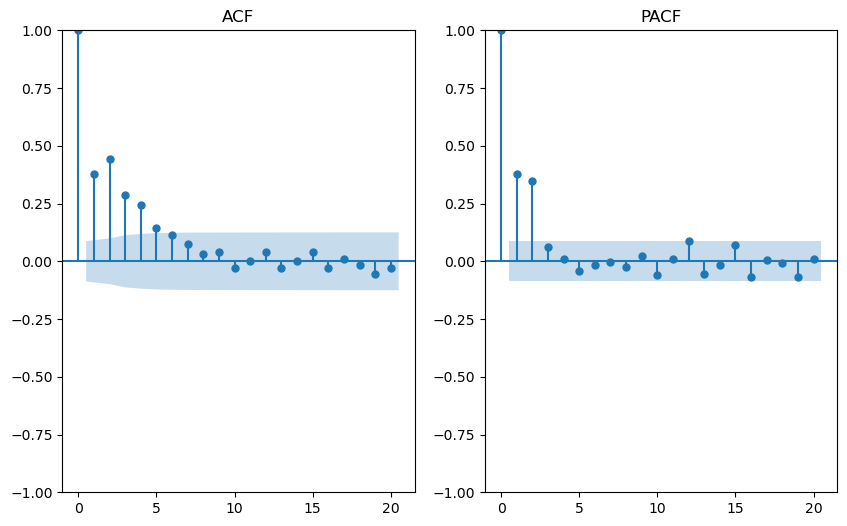

In [11]:
#look at residuals of OLS to determine ideal order of residual model
y = df['Mortality']
x = df[['Time', 'Temp Centered', 'Temp Centered Squared', 'Particulates', 'Particulates Lagged (4)']]
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())
resids = model.resid
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
plot_acf(resids, ax=axes[0], lags=lags, title="ACF")
plot_pacf(resids, ax=axes[1], lags=lags, title="PACF")
plt.show()

In [12]:
#residual plot suggests an AR(2)
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(y, exog=x, order=(2,0,0))
modelFit = model.fit()
modelFit.summary()

C:\Users\jmeek\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\jmeek\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\jmeek\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              Mortality   No. Observations:                  504
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -1532.115
Date:                Sat, 25 Jul 2026   AIC                           3082.230
Time:                        21:58:49   BIC                           3120.233
Sample:                             0   HQIC                          3097.137
                                - 504                                         
Covariance Type:                  opg                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      79.2658      2.646     29.957      0.000      74.080      84.452
Time                       -0.0197      0.008     -2.584      0.010      -0.035      -0.005
Temp Centered              -0.0661      0.040     -1.669      0.095      -0.144       0.012
Temp Centered Squared       0.0158      0.002      8.125      0.000       0.012       0.020
Particulates                0.1832      0.024      7.583      0.000       0.136       0.231
Particulates Lagged (4)     0.0798      0.020      4.090      0.000       0.042       0.118
ar.L1                       0.3710      0.038      9.811      0.000       0.297       0.445
ar.L2                       0.4120      0.043      9.632      0.000       0.328       0.496
sigma2                     25.6193      1.545     16.586      0.000      22.592      28.647
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 8.83
Prob(Q):                              0.73   Prob(JB):                         0.01
Heteroskedasticity (H):               0.71   Skew:                             0.27
Prob(H) (two-sided):                  0.03   Kurtosis:                         3.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Particulates lagged (4) is a very statistically significant predictor in this regression with a p-value well below 0.05. Comparing the AIC and BIC from the OLS regression to the time-series regression with an AR(2) regression model, the AIC and BIC are both lower for the time-series regression, suggesting that this model fits the data better and is thus an improvement.

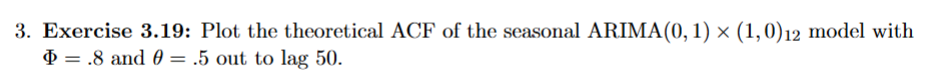

<StemContainer object of 3 artists>

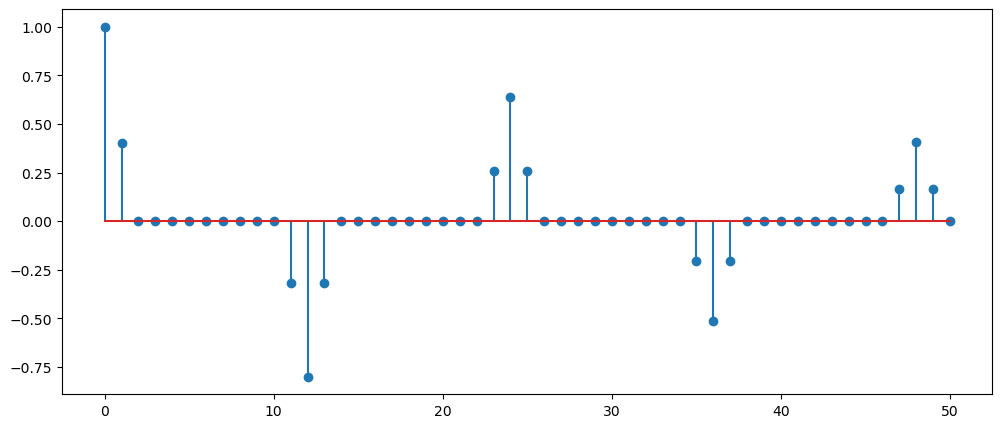

In [13]:
from statsmodels.tsa.arima_process import ArmaProcess
arArray = np.zeros(13)
arArray[0] = 1
arArray[12] = 0.8
maArray = np.array([1, 0.5])
model = ArmaProcess(arArray, maArray)
data = model.acf(lags=51)
plt.figure(figsize=(12, 5))
plt.stem(np.arange(51), data)

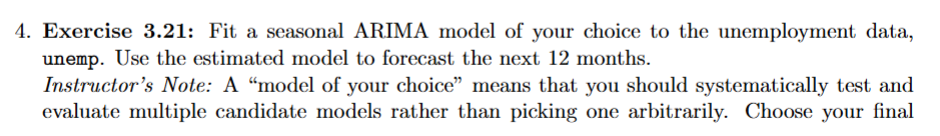
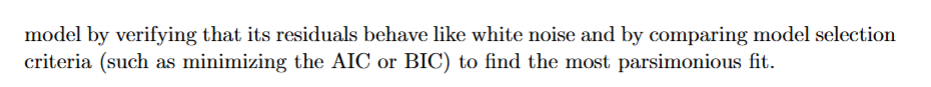

In [14]:
df = pd.read_csv("unemp.csv")
df['Time Index'] = np.arange(0, len(df), 1)

<Axes: xlabel='Time Index', ylabel='Value'>

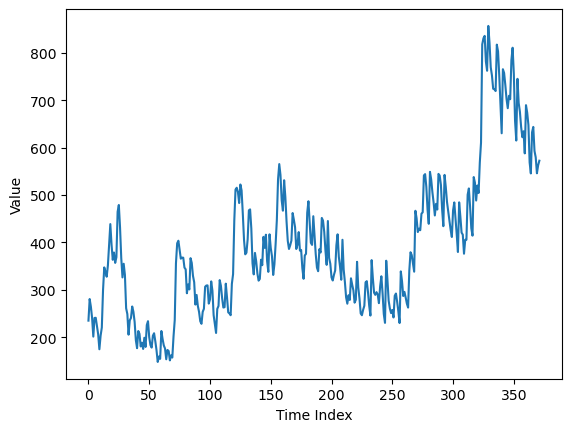

In [15]:
sns.lineplot(x=df['Time Index'], y=df['Value'])

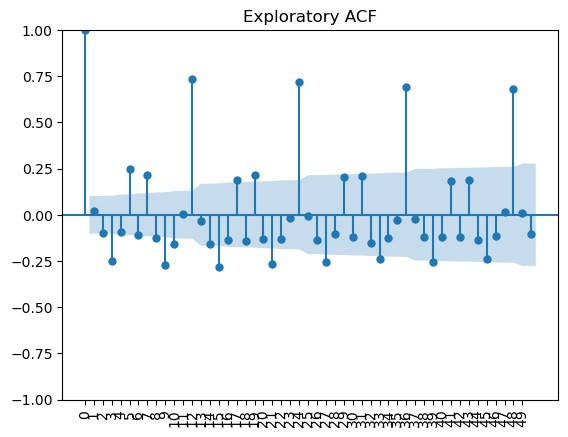

In [16]:
#taking the log as varaiance appears to increase over time
#taking first difference since there is a clear trend
df['Log Value Diff'] = np.log(df['Value']).diff() 
#looking at acf to see what seasonal difference we should take
plot_acf(df['Log Value Diff'].dropna(), lags=50, title="Exploratory ACF")
plt.xticks(np.arange(0,50,1))
plt.xticks(rotation=90)
plt.show()
#pretty clear seasonal trend at t=12,24...n12
#thus...
df['Log Value Diff'] = np.log(df['Value']).diff(1).diff(12) 

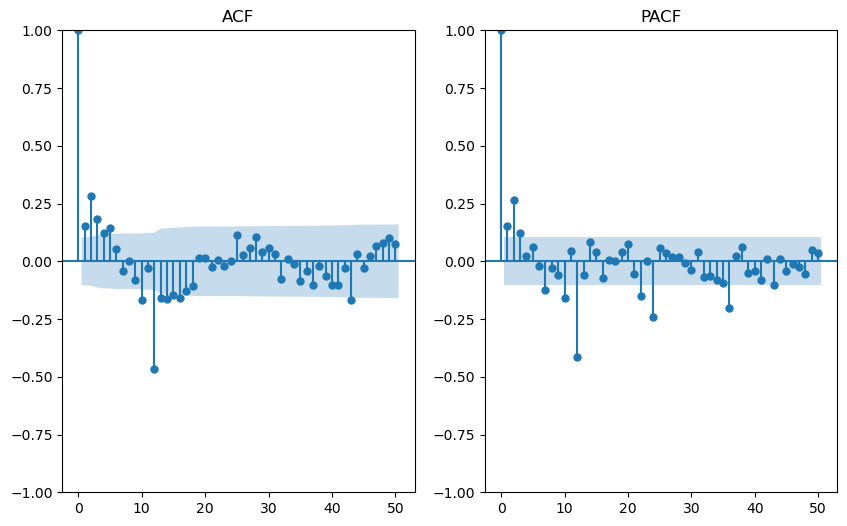

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
lags = 50
plot_acf(df['Log Value Diff'].dropna(), ax=axes[0], lags=lags, title="ACF")
plot_pacf(df['Log Value Diff'].dropna(), ax=axes[1], lags=lags, title="PACF")
plt.show()

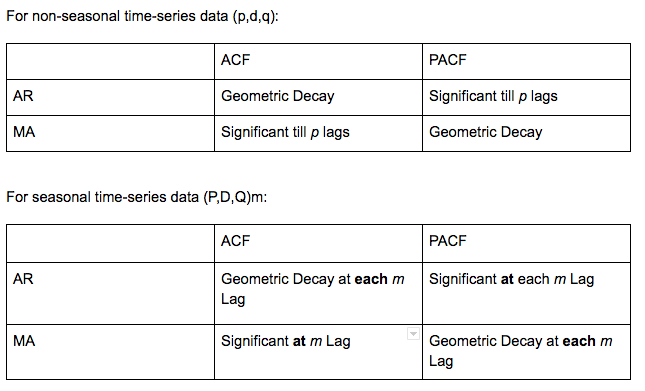

In [18]:
#clearly need a MA(12) seasonal component, for the regular component we will try (1,1), (2,1), and (1,2) since the ACF and PACF both appear to decay exponentially
y = np.log(df['Value'])
models = [
    ((1,1,1), (0,1,1,12)), 
    ((2,1,1), (0,1,1,12)), 
    ((1,1,2), (0,1,1,12)), 
]
results = []
for order, sorder in models:
    model = SARIMAX(y, order=order, seasonal_order=sorder)
    modelFit = model.fit()
    results.append({
        'Order': str(order),
        'Seasonal Order': str(sorder),
        'AIC': modelFit.aic,
        'BIC': modelFit.bic
    })
resultsDF = pd.DataFrame(results)
print(resultsDF)

       Order Seasonal Order         AIC         BIC
0  (1, 1, 1)  (0, 1, 1, 12) -975.674875 -960.141585
1  (2, 1, 1)  (0, 1, 1, 12) -979.462116 -960.045504
2  (1, 1, 2)  (0, 1, 1, 12) -979.568448 -960.151836


Given the results above, the model SARIMA(1,1,1) (0,1,1,12) is superior as it minimizes AIC while having a nearly identical BIC. 
Double checking residuals below:

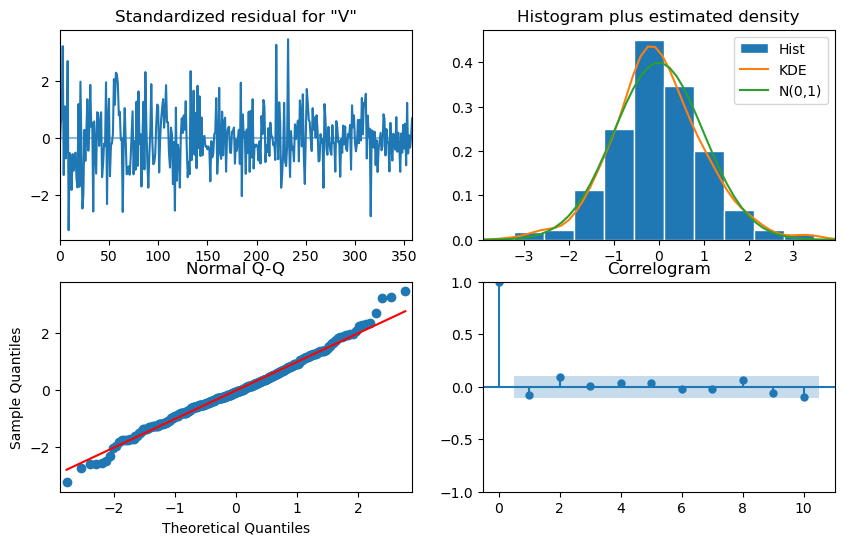

In [19]:
model = SARIMAX(y, order=(1,1,1), seasonal_order=(0,1,1,12))
modelFit = model.fit()
modelFit.plot_diagnostics(figsize=(10,6))
plt.show()

Residuals look normal, white noise

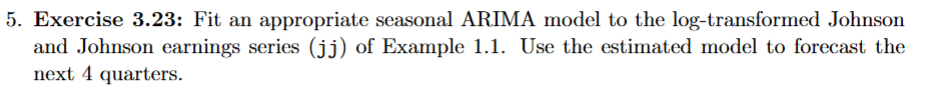

In [20]:
df = pd.read_csv("jj.csv")
df['Time Index'] = np.arange(0, len(df), 1)

<Axes: xlabel='Time Index', ylabel='Value'>

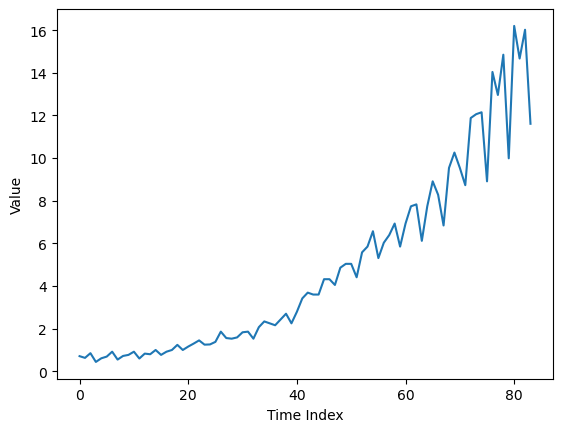

In [21]:
sns.lineplot(x=df['Time Index'], y=df['Value'])

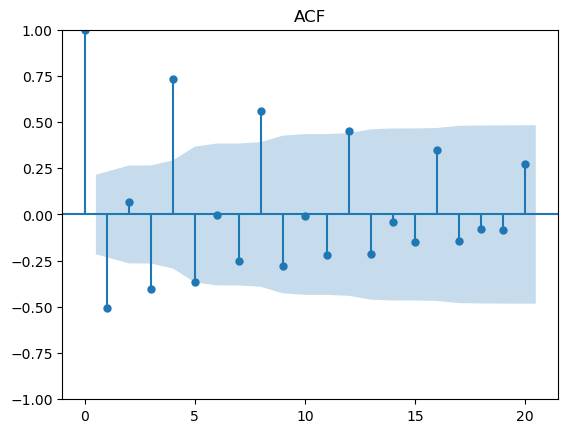

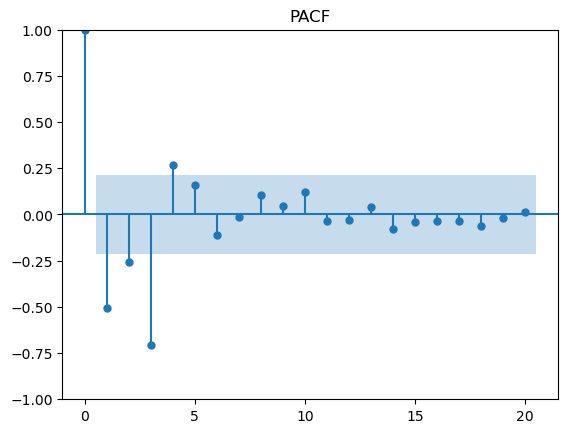

In [22]:
#clear need to take first difference and log, no obvious seasonal trend yet
df['Log Difference'] = np.log(df['Value']).diff()
plot_acf(df['Log Difference'].dropna(), lags=20, title = 'ACF')
plot_pacf(df['Log Difference'].dropna(), lags=20, title = 'PACF')
plt.show()

In [23]:
#model candidates: (3,1,0), (1, 1, 0, 4) or (3,1,1), (1,1,0,4)
y = np.log(df['Value'])
models = [
    ((3,1,0), (1,1,0,4)), 
      ((3,1,1), (1,1,0,4))
]
results = []
for order, sorder in models:
    model = SARIMAX(y, order=order, seasonal_order=sorder)
    modelFit = model.fit()
    results.append({
        'Order': str(order),
        'Seasonal Order': str(sorder),
        'AIC': modelFit.aic,
        'BIC': modelFit.bic
    })
resultsDF = pd.DataFrame(results)
print(resultsDF)
#going with the first model as second model had convergence error despite second model having improved BIC

       Order Seasonal Order         AIC         BIC
0  (3, 1, 0)   (1, 1, 0, 4) -147.015758 -135.168519
1  (3, 1, 1)   (1, 1, 0, 4) -147.586388 -133.369701


C:\Users\jmeek\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


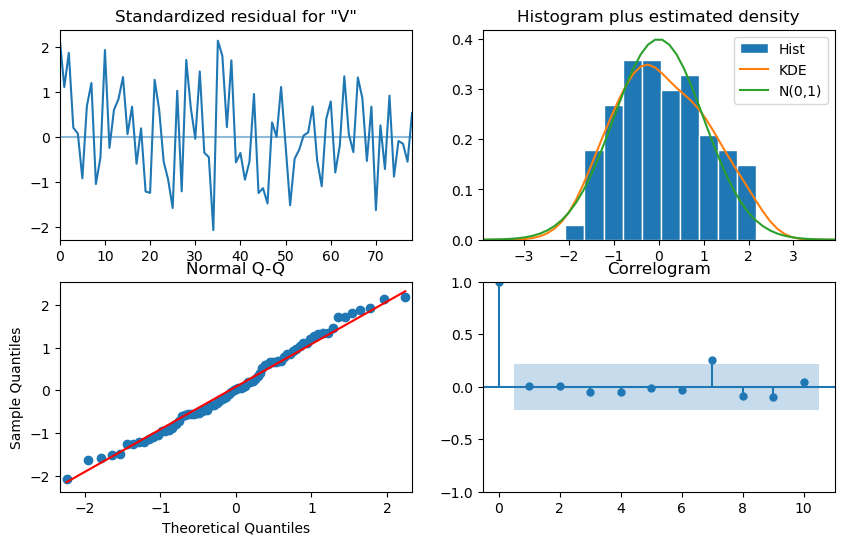

In [24]:
model = SARIMAX(y, order=(3,1,0), seasonal_order=(1,1,0,4))
modelFit = model.fit()
modelFit.plot_diagnostics(figsize=(10,6))
plt.show()
#residuals appear normal, white noise

Next four quarters:

In [25]:
preds = modelFit.get_forecast(steps=4)
predsScaled = np.exp(preds.predicted_mean)
print(f"The forecast for the next four quarters of Johnson and Johnson EPS are {predsScaled.values}")

The forecast for the next four quarters of Johnson and Johnson EPS are [18.38280262 16.6970432  18.58251857 13.10902249]
